# Face Alignment

## Выбор датасета

В этом проекте мы будем работать с датасетом [CelebA - Original Wild Images](https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). Обычно, когда говорят про CelebA имеют ввиду его кропнутую и выровненную версию, но мы будем работать с сырой.

![CelebA](https://figures.semanticscholar.org/7df4f96138a4e23492ea96cf921794fc5287ba72/6-Figure4-1.png)

Оригинальная версия датасета весит очень много: ~20 гб. Все картинки нам не будут нужны, достаточно будет ограничиться 10.000+.

Вашим первым заданием будет подготовить себе рабочий датасет. Он будет использован и в следующих заданиях, поэтому подойдите к этому очень ответственно:

- Скачайте себе датасет CelebA In a Wild любым удобным способом;
- Подумайте над тем, по каким критериям лучше всего выбирать картинки. Используйте файл с атрибутами. Обоснуйте свой выбор текстом. В случае, если обоснования выбора датасета не будет, то баллы могут быть снижены. Отнеситесь к этому серьезно: хорошая подготовка данных очень важна;
- Отберите 10.000+ изображений. Можно и больше при желании;
- При помощи атрибутов bbox'а, обрежьте картинки, чтобы на них остались только лица. При желании можно делать дополнительный кроп, так как не везде разметка идеальна, но не нужно сидеть над каждой картинкой отдельно - потратите слишком много времени;
- Сохраните отдельный csv-файл с оригинальными названиями изображений, которые были отобраны в ваш датасет. В дальнейшем он в том числе понадобится для сдачи проекта.

Несколько практических советов:
- Отнеситесь очень ответственно к отбору данных, это важнейшая часть проекта. Заранее лучше закладывайте время на то, что, очень вероятно, вам придется делать отбор заново по ходу осознания всех заданий.
- Если решили делать дополнительный кроп изображений самостоятельно, то имейте ввиду, что ключевые точки лица в атрибутах указаны в начальной системе координат.
- При первичном анализе и отборе данных не работайте в колабе. Простейшую работу с файлами удобнее делать локально на своем компьютере. Это не требует мощного железа и скачивания библиотек. Если все же пользуетесь колабом, то работайте на CPU, чтобы не лишний раз не тратить токены.
- Если есть возможность, то не удаляйте оригинальный датасет с вашего компьютера на период работы над проектом. Да, это лишняя занятая память, но зато при надобности можно будет быстро что-то изменить.
- Загрузите финальный датасет (10.000+ картинок) себе на Google Disk. Это удобнее, чем каждый раз отдельно загружать его себе в колаб сессию.

## Архитектура Stacked Hourglass Network

В разных вариантах пайплайна для распознавания лиц ключевые точки лица могут предсказываться сразу детектором (MTCNN, RetinaFace и прочие), а могут и отдельной моделью. В этом проекте рассматривается второй вариант. То есть, за детекцию ключевых точек будет отвечать отдельная модель.

**Hourglass** — это U-Net-подобная структура, которая сначала уменьшает разрешение изображения, затем восстанавливает его обратно. Такая структура напоминает по форме песочные часы (hourglass).

**Stacked Hourglass Network** состоит Hourglass-блоков, каждый из которых старается уточнять результат предыдущего. Несмотря на то, что она придумана в 2016 году, до сих пор используется во многих исследовательских проектах для задачи обнаружения ключевых точек.

![image](https://img2018.cnblogs.com/blog/900393/201907/900393-20190722093153502-1808128161.png)

### Hourglass module

Посмотрим подробнее на структуру **отдельного Hourglass-блока**

![retrt](https://curt-park.github.io/images/stacked_hourglass_networks/fig3.png)

Каждый бокс в этой схеме - это Residual block, который отвечает за извлечение признаков на разных уровнях детализации (вспоминаем про ResNet). Причем, каждый такой блок имеет одинаковую размерность на входе и на выходе.

Downsampling и upsampling можно делать разными способами.

*   Для Downsampling: nn.MaxPool2d или nn.Conv2d
*   Для Upsampling: nn.Upsample или nn.ConvTranspose2d

Основная разница: maxpool и upsample - необучаемые слои в отличие от сверток. Это может как быть как минусом, так и плюсом: чем больше параметров - тем медленее идет процесс обучения (при этом не факт, что результаты будут лучше).

То есть, идейно все практически также как было в U-net: полностью симметричная архитектура, сначала идет преобразование в более низкоразмерное пространство, а потом декодирование обратно с пробросами результатов из соотвествующих слоев энкодера. Разница лишь в том, что теперь каждый кирпичик - это Residual block.

А вот реализация ResidualBlock вам в помощь!

Но можете ее править под себя, если очень хочется.

При построении архитектуры Hourglass-блоков **не обязательно полностью повторять архитектуру**, которая представлена на картинке из статьи. Вы можете добавлять больше или меньше модулей, некоторые блоки вообще можно не использовать. В целом, это творческая задача и вы вольны делать так, как вам самим хочется. **Главное - чтобы ваша реализация соотвествовала изначальной идее Hourglass, и итоговые результаты были достаточно хорошими.**

### Stacked Hourglass Network

Как и было сказано ранее, Stacked Hourglass - это набор одинаковых Hourglass блоков (см. схематический рисунок в начале ноутбука). Но что это за блок между каждыми двумя Hourglass? Чтобы ответить на этот вопрос, нужно сначала разобраться с тем, что мы будем получать на выходе такой нейронной сети.

Предсказывать ключевые точки лица можно поразному. Есть два основных подхода:

1.   Регрессия - предсказывает координаты точек лица напрямую -> $(N, x, y)$.
2.   Heatmap - предсказывает карту вероятностей на выходе, а наиболее подходящие точки находятся через argmax

Не вдваясь в подробности, можно просто сказать, что Heatmap-подход показал себя лучше из-за своей устойчивости к шумам и начальным условиям. В качестве функции потерь в таком случае используют обычный **MSE loss**.

В Stacked Hourglass **используется именно heatmap-подход**. И на выходе каждого Hourglass-блока находится слой (голова), который создает heatmap нужного размера. Обычно это какие-то стандартные варианты по типу *Conv -> BatchNorm -> Relu -> Conv* или просто *Conv*. Каждая heatmap'a прокидывается на следующую голову, и они суммируются, и так, пока слои не закончатся.

Такой подход нужен для реализации **Intermediate Supervision**. Если говорить простыми словами, то это такой вариант обучения нейронной сети, когда мы подсчитываем лосс не только по финальному выходу сети, а также на некоторых промежуточных слоях (головах). Градиенты в этом случае тоже распространяются не только через последний выход, но и через промежуточные уровни. Эти головы не влияют на финальное предсказание напрямую, но помогают модели быстрее и лучше учиться. На практике это означет следующее:

Нужно посчитать лосс (таргет для всех одинаковый) для каждой головы отдельно, а потом просуммировать. Далее Pytorch сам построит за вас весь граф вычислений и правильно запустит везде градиенты. В коде это выглядит так:

```
outputs = model(image)  # outputs — список из N heatmaps от разных голов
losses = [loss_function(output, target) for output in outputs]
total_loss = sum(losses)
total_loss.backward()
optimizer.step()
```

Подведем **итоги по архитектуре**.

Stacked Hourglass состоит из Hourglass-блоков, после каждого такого блока идет голова, которая предсказывает heatmap'у. Каждая heatmap'а суммируется с предыдущей. Градиенты при обучении текут с каждой головы, а не только через последний выход сети.

Подробно про Stacked Hourglass Network можно прочитать в [оригинальной статье](https://arxiv.org/pdf/1603.06937).

## Подготовка датасета для обучения

На этом этапе у вас уже должен быть готовый датасет на основе CelebA In A Wild.

В разметке CelebA всего 5 точек:

1.   Левый глаз
2.   Правый глаз
3.   Нос
4.   Левый уголок рта
5.   Правый уголок рта


Единственная проблема заключается в том, что разметка - это именно точки, а не heatmap'ы. Но можно их сгенерировать самостоятельно при помощи гауссовского распределения вокруг размеченных точек. Вот вам функции в помощь. Можете их тоже редактивовать под себя, если нужно.

## Выравнивание по предсказанным точкам

Существует множество вариантов, как по полученным точкам правильно преобразовать картинку. Главное, что вам нужно понимать - **это задача классического компьютерного зрения** и решается при помощи математики, без нейронок. Вдаваться в подробности конкретных алгоритмов мы не будем.

Можно использовать аффинное преобразование, тогда потребуется только 3 точки, можно, например, искать матрицу гомографии, где может быть использовано больше точек, а может быть, есть еще что-то. Реализовывать эти алгоритмы самим не нужно. Достаточно провести небольшой ресерч и найти готовое решение (но **не готовую нейронку для выравнивания**), лишь бы оно работало. Количество используемых точек тоже выбирайте сами, подойдет любой вариант. Условный ориентир для поиска - библиотека **opencv**. Обязательно приведите примеры того, как работает ваш алгоритм.

# План заданий

По итогу, в этом блоке у вас следующие задачи:

*   Подготовить датасет, сохранить файл с оригинальными названиями изображений
*   Реализовать Hourglass блок
*   Реализовать Stacked Hourglass
*   Преобразовать точки лица в Heatmap'ы
*   Обучить Stacked Hourglass
*   Найти функцию, которая по предсказанным ключевым точкам выравнивает лица на картинке (face alignment)
*   Подготовить датасет с кропнутыми и выровненными лицами для следующего этапа

**P.S. Не забывайте сохранять модели после обучения и выводите промежуточные результаты на экран**



**Удачи! У вас всё получится 💗!**

In [ ]:
import pandas as pd
import zipfile
import os
from torch.utils.data import Dataset, DataLoader
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path='/content/drive/MyDrive/FR_project/train_data_cropped.zip'
extract_to = '/content/'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_to)



zip_path='/content/drive/MyDrive/FR_project/val_data_cropped.zip'
extract_to = '/content/'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_to)

In [ ]:
def load_landmarks(file_path):
    landmarks_dict = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:
            parts = line.strip().split()
            if not parts:
                continue
            filename = parts[0]
            points = list(map(float, parts[1:]))
            landmarks = [(points[i], points[i+1]) for i in range(0, len(points), 2)]
            landmarks_dict[filename] = landmarks
    return landmarks_dict

train_landmarks = load_landmarks('/content/drive/MyDrive/FR_project/split_landmarks_cropped/train_landmarks.txt')
val_landmarks = load_landmarks('/content/drive/MyDrive/FR_project/split_landmarks_cropped/val_landmarks.txt')

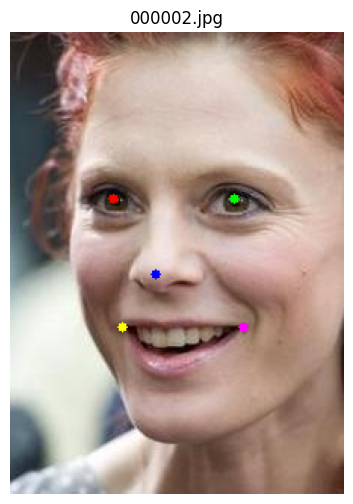

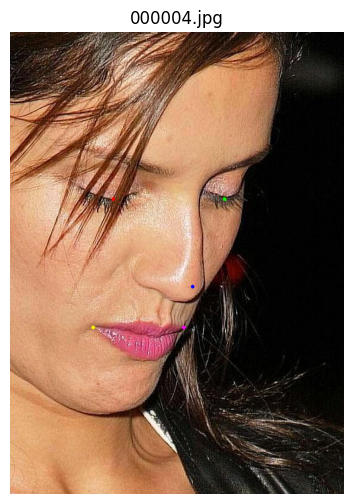

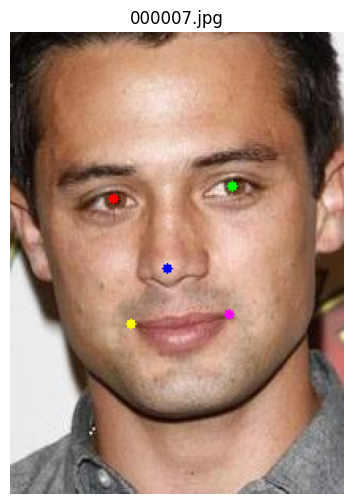

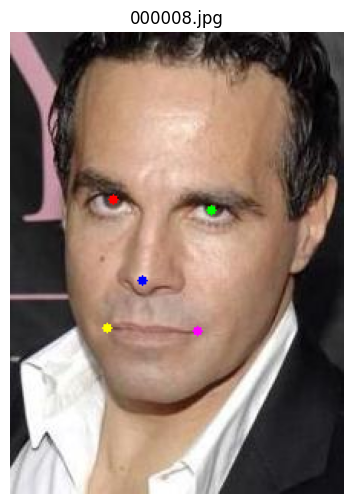

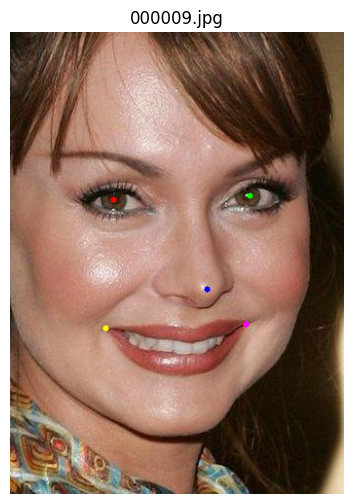

In [ ]:
# Проверка что координаты нужные
def visualize_sample(annotations_df, img_dir, num_samples=5):
    for idx, row in annotations_df.head(num_samples).iterrows():
        img_path = os.path.join(img_dir, row['filename'])
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Точки
        points = [
            (row['lefteye_x'], row['lefteye_y']),
            (row['righteye_x'], row['righteye_y']),
            (row['nose_x'], row['nose_y']),
            (row['leftmouth_x'], row['leftmouth_y']),
            (row['rightmouth_x'], row['rightmouth_y'])
        ]

        colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255)]
        for i, (x, y) in enumerate(points):
            cv2.circle(img_rgb, (int(x), int(y)), 3, colors[i], -1)

        plt.figure(figsize=(6,6))
        plt.imshow(img_rgb)
        plt.title(f"{row['filename']}")
        plt.axis('off')
        plt.show()

# Проверяем
train_anno = pd.read_csv("/content/drive/MyDrive/FR_project/split_landmarks_cropped/train_landmarks.txt", sep=' ')
visualize_sample(train_anno, "/content/train_data_cropped")

In [ ]:
def create_heatmap(size, landmark, sigma=2):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.

    :param size: (height, width) — размер heatmap'а
    :param landmark:(x, y) — координаты точки
    :param sigma
    :return: heatmap массив
    """
    x, y = landmark
    h, w = size

    # Обрезаем координаты, чтобы не выйти за пределы изображения
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в набор из N heatmap'ов.

    :param image_shape: исходный размер изображения (H, W)
    :param landmarks: список из N пар координат [(x1, y1), (x2, y2), ..., (xN, yN),]
    :param sigma:
    :return: массив heatmap'ов вида [N, H, W]
    """
    heatmaps = []

    for (x, y) in landmarks:
        hm = create_heatmap(image_shape, (x, y), sigma=sigma)
        heatmaps.append(hm)

    return np.array(heatmaps)

In [ ]:
class FaceLandmarkDataset(Dataset):
    def __init__(self, images_dir, landmarks_dict, target_size=(256, 256), heatmap_size=(64, 64), sigma=2):
        self.images_dir = images_dir
        self.landmarks_dict = landmarks_dict
        self.target_size = target_size
        self.heatmap_size = heatmap_size
        self.sigma = sigma
        self.filenames = list(landmarks_dict.keys())

        # Сохраняем оригинальные размеры для масштабирования координат
        self.original_sizes = {}
        for filename in self.filenames:
            img_path = os.path.join(images_dir, filename)
            img = cv2.imread(img_path)
            if img is not None:
                self.original_sizes[filename] = img.shape[:2]  # (h, w)
            else:
                print(f"Warning: Could not load {img_path}")
                self.original_sizes[filename] = (256, 256)

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]

        # 1. Загружаем изображение
        img_path = os.path.join(self.images_dir, filename)
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Could not load image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2. Получаем оригинальный размер и координаты
        orig_h, orig_w = self.original_sizes[filename]
        landmarks = self.landmarks_dict[filename]

        # 3. Изменяем размер изображения
        target_h, target_w = self.target_size
        image = cv2.resize(image, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

        # 4. Масштабируем координаты под размер изображения (для визуализации батча)
        scaled_landmarks = []
        for (x, y) in landmarks:
            new_x = x * (target_w / orig_w)
            new_y = y * (target_h / orig_h)
            scaled_landmarks.append((new_x, new_y))

        # 5. Масштабируем координаты под размер heatmapы
        hm_h, hm_w = self.heatmap_size
        hm_landmarks = []
        for (x, y) in scaled_landmarks:
            # Масштабируем от размера изображения к размеру heatmapы
            hm_x = x * (hm_w / target_w)
            hm_y = y * (hm_h / target_h)
            hm_landmarks.append((hm_x, hm_y))

        # 6. Нормализация изображения [0, 1] и HWC -> CHW
        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        # 7. Генерируем heatmapы в размере heatmap_size
        heatmaps = landmarks_to_heatmaps(self.heatmap_size, hm_landmarks, self.sigma)

        return torch.FloatTensor(image), torch.FloatTensor(heatmaps)

In [ ]:
# Создаем датасеты
train_dataset = FaceLandmarkDataset(
    images_dir='/content/train_data_cropped/',
    landmarks_dict=train_landmarks,
    target_size=(256, 256),
    heatmap_size=(64, 64),
    sigma=2
)

val_dataset = FaceLandmarkDataset(
    images_dir='/content/val_data_cropped/',
    landmarks_dict=val_landmarks,
    target_size=(256, 256),
    heatmap_size=(64, 64),
    sigma=2
)

# Создаем DataLoader'ы
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
def visualize_batch(dataloader, num_samples=4):
    images, heatmaps = next(iter(dataloader))

    for i in range(min(num_samples, images.shape[0])):
        h, w = heatmaps.shape[2], heatmaps.shape[3]
        coords_hm = []
        coords_img = []

        for p in range(heatmaps.shape[1]):
            hm = heatmaps[i, p].numpy()
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            coords_hm.append((x, y))

            # Масштабируем координаты из heatmap'а (64x64) в изображение (256x256)
            scale_x = 256 / 64
            scale_y = 256 / 64
            coords_img.append((x * scale_x, y * scale_y))

        plt.figure(figsize=(5, 5))
        img = np.transpose(images[i].numpy(), (1, 2, 0))
        plt.imshow(img)

        for x, y in coords_img:
            plt.scatter(x, y, c='red', s=20)

        plt.title(f"Sample {i+1} (heatmap size: {h}x{w})")
        plt.axis('off')
        plt.show()

        plt.figure(figsize=(3, 3))
        plt.imshow(heatmaps[i, 0].numpy(), cmap='hot')
        plt.title(f"Хитмапа, точка 1 (64x64)")
        plt.axis('off')
        plt.show()

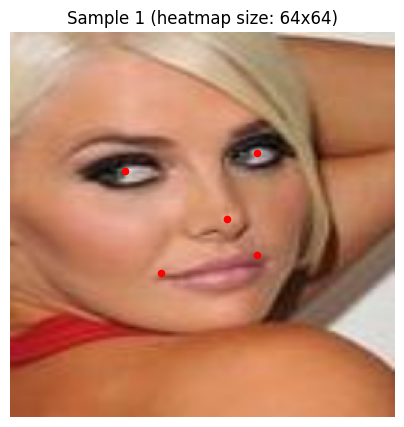

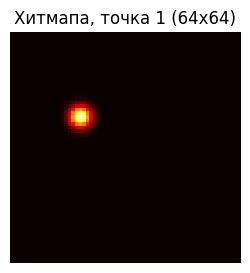

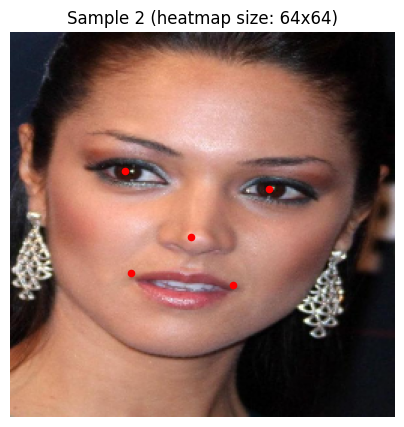

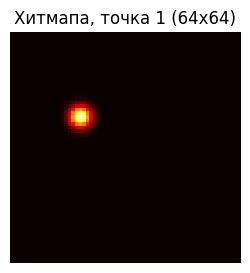

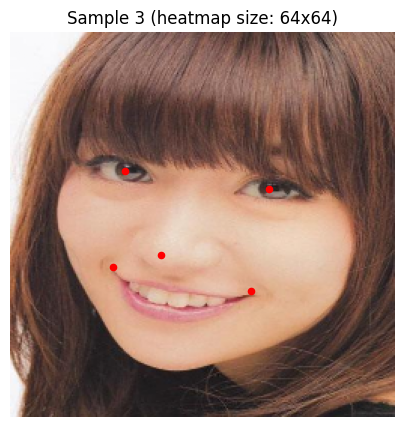

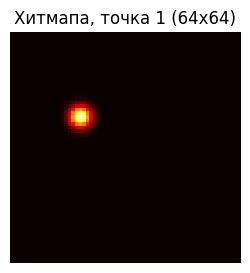

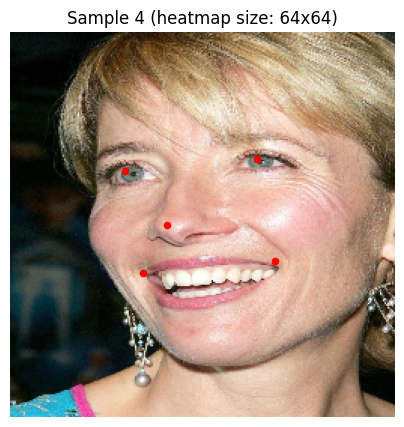

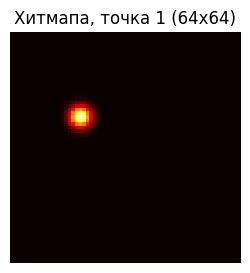

In [ ]:
visualize_batch(train_loader)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, 1)

        self.conv1 = nn.Conv2d(in_channels, out_channels // 2, 1)
        self.bn1 = nn.BatchNorm2d(out_channels // 2)
        self.conv2 = nn.Conv2d(out_channels // 2, out_channels // 2, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels // 2)
        self.conv3 = nn.Conv2d(out_channels // 2, out_channels, 1)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        return self.relu(x + residual)

In [ ]:
class HourglassBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.skip = ResidualBlock(in_channels, out_channels)

        # Level 1: H/2
        self.down1 = nn.Sequential(
            ResidualBlock(in_channels, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Level 2: H/4
        self.down2 = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Level 3: H/8
        self.down3 = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Level 4: H/16 (самый низкий)
        self.down4 = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            nn.MaxPool2d(2, stride=2)
        )

        # Bottom (самый низкий уровень)
        self.bottom = nn.Sequential(
            ResidualBlock(out_channels // 2, out_channels // 2),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 4 -> 3 (H/16 -> H/8)
        self.up4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 3 -> 2 (H/8 -> H/4)
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 2 -> 1 (H/4 -> H/2)
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels // 2)
        )

        # Upsampling level 1 -> original (H/2 -> H)
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            ResidualBlock(out_channels // 2, out_channels)
        )

        # Final - используем обычную свертку вместо ResidualBlock
        # потому что ResidualBlock требует четное количество входных каналов
        # и делает out_channels // 2
        self.final = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip = self.skip(x)

        # Downsampling path
        d1 = self.down1(x)      # H/2
        d2 = self.down2(d1)     # H/4
        d3 = self.down3(d2)     # H/8
        d4 = self.down4(d3)     # H/16

        # Bottom
        bottom = self.bottom(d4)  # H/16

        # Upsampling path with skip connections
        up4 = self.up4(bottom)    # H/16 -> H/8
        up4 = up4 + d3            # Складываем с d3 (H/8)

        up3 = self.up3(up4)       # H/8 -> H/4
        up3 = up3 + d2            # Складываем с d2 (H/4)

        up2 = self.up2(up3)       # H/4 -> H/2
        up2 = up2 + d1            # Складываем с d1 (H/2)

        up1 = self.up1(up2)       # H/2 -> H
        up1 = up1 + skip          # Складываем с skip (H)

        # Конкатенируем up1 и skip для финальной свертки
        out = self.final(torch.cat([up1, skip], dim=1))

        return out

In [ ]:
class StackedHourglass(nn.Module):
    def __init__(self, in_channels=3, num_stacks=4, num_keypoints=5, hidden_channels=256):
        super().__init__()
        self.num_stacks = num_stacks
        self.num_keypoints = num_keypoints
        self.hidden_channels = hidden_channels

        # Начальная обработка (как в статье)
        self.input_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64, 128),
            nn.MaxPool2d(2, stride=2),
            ResidualBlock(128, 128),
            ResidualBlock(128, hidden_channels)
        )

        # Стеки
        self.hourglass_stacks = nn.ModuleList()
        self.heads = nn.ModuleList()
        self.intermediate_convs = nn.ModuleList()

        for i in range(num_stacks):
            self.hourglass_stacks.append(
                HourglassBlock(hidden_channels, hidden_channels)
            )

            self.heads.append(
                nn.Conv2d(hidden_channels, num_keypoints, 1)
            )

            if i < num_stacks - 1:
                self.intermediate_convs.append(
                    nn.Sequential(
                        nn.Conv2d(hidden_channels + num_keypoints, hidden_channels, 1),
                        nn.BatchNorm2d(hidden_channels),
                        nn.ReLU(inplace=True)
                    )
                )

    def forward(self, x):
        x = self.input_conv(x)

        all_heatmaps = []
        residual = None

        for i in range(self.num_stacks):
            hg_out = self.hourglass_stacks[i](x)
            heatmap = self.heads[i](hg_out)
            all_heatmaps.append(heatmap)

            if i < self.num_stacks - 1:
                combined = torch.cat([hg_out, heatmap], dim=1)
                x = self.intermediate_convs[i](combined)
                if residual is not None:
                    x = x + residual
                residual = x

        return all_heatmaps

In [ ]:
def heatmap_loss(predicted_heatmaps, target_heatmap):
    mse = nn.MSELoss()
    return sum(mse(pred, target_heatmap) for pred in predicted_heatmaps)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Функция для преобразования heatmap в координаты
def heatmap_to_keypoints(heatmap):
    batch_size = heatmap.shape[0]
    num_keypoints = heatmap.shape[1]
    h, w = heatmap.shape[2], heatmap.shape[3]

    keypoints = []
    for b in range(batch_size):
        points = []
        for k in range(num_keypoints):
            hm = heatmap[b, k, :, :]
            _, idx = hm.flatten().max(dim=0)
            y = idx // w
            x = idx % w
            points.append((x.item(), y.item()))
        keypoints.append(points)

    return keypoints

In [ ]:
model = StackedHourglass(
    in_channels=3,
    num_stacks=4,
    num_keypoints=5,
    hidden_channels=256
)
model.to(device)

StackedHourglass(
  (input_conv): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ResidualBlock(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ResidualBlock(
      (skip): Identity()
      (con

Validation: 100%|██████████| 32/32 [00:26<00:00,  1.21it/s, loss=0.0112]


Сохранена лучшая модель, (val_loss: 0.011071)
Epoch 1/10 | Train Loss: 0.029391 | Val Loss: 0.011071 | Time: 793.4s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.21it/s, loss=0.00734]


Сохранена лучшая модель, (val_loss: 0.007118)
Epoch 2/10 | Train Loss: 0.008779 | Val Loss: 0.007118 | Time: 803.3s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.22it/s, loss=0.00522]


Сохранена лучшая модель, (val_loss: 0.005196)
Epoch 3/10 | Train Loss: 0.005834 | Val Loss: 0.005196 | Time: 803.5s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.22it/s, loss=0.00414]


Сохранена лучшая модель, (val_loss: 0.004065)
Epoch 4/10 | Train Loss: 0.004391 | Val Loss: 0.004065 | Time: 803.2s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.22it/s, loss=0.00336]


Сохранена лучшая модель, (val_loss: 0.003256)
Epoch 5/10 | Train Loss: 0.003440 | Val Loss: 0.003256 | Time: 802.2s
------------------------------------------------------------


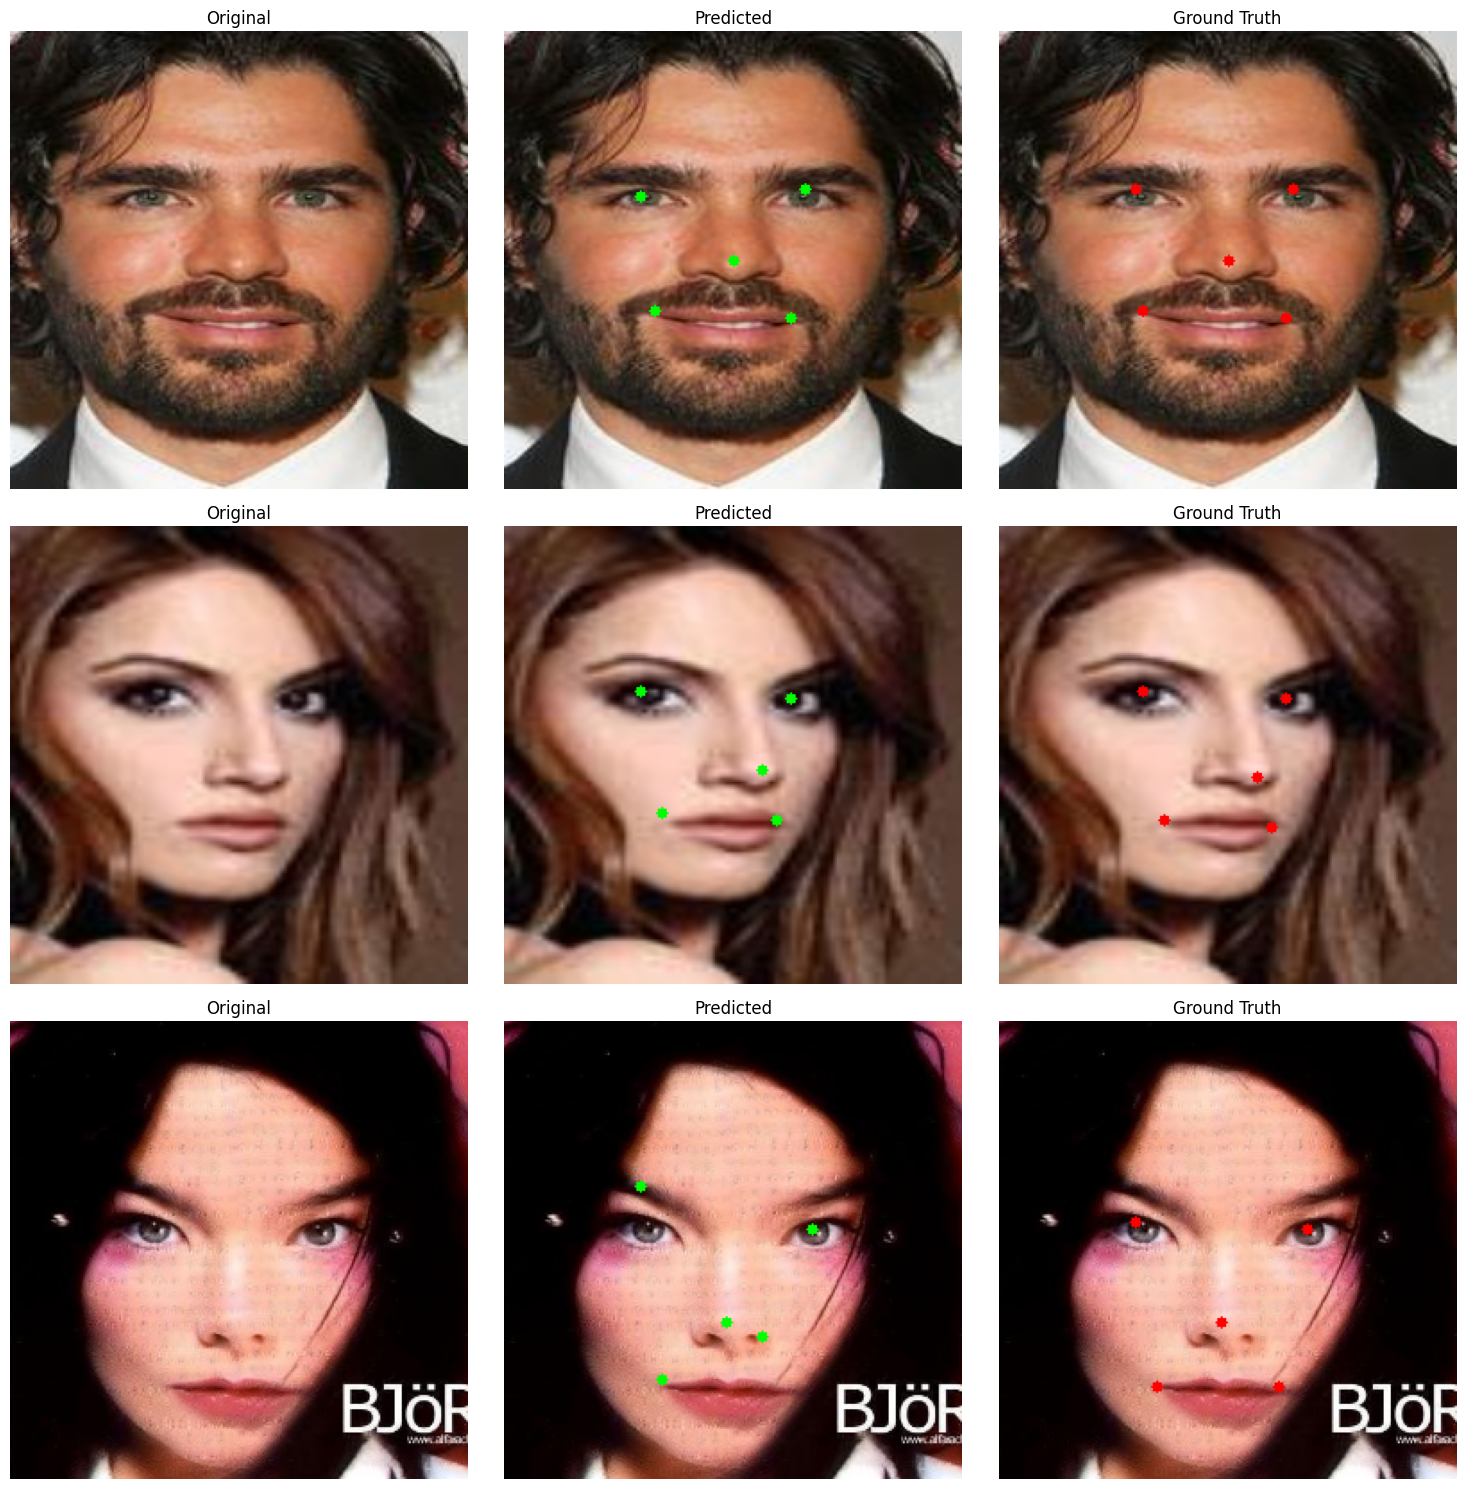

Validation: 100%|██████████| 32/32 [00:26<00:00,  1.22it/s, loss=0.00272]


Сохранена лучшая модель, (val_loss: 0.002521)
Epoch 6/10 | Train Loss: 0.002714 | Val Loss: 0.002521 | Time: 802.3s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.22it/s, loss=0.00205]


Сохранена лучшая модель, (val_loss: 0.001901)
Epoch 7/10 | Train Loss: 0.002013 | Val Loss: 0.001901 | Time: 802.3s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.23it/s, loss=0.00166]


Сохранена лучшая модель, (val_loss: 0.001570)
Epoch 8/10 | Train Loss: 0.001550 | Val Loss: 0.001570 | Time: 801.9s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.21it/s, loss=0.00141]


Сохранена лучшая модель, (val_loss: 0.001370)
Epoch 9/10 | Train Loss: 0.001285 | Val Loss: 0.001370 | Time: 800.9s
------------------------------------------------------------


Validation: 100%|██████████| 32/32 [00:26<00:00,  1.22it/s, loss=0.00115]


Сохранена лучшая модель, (val_loss: 0.001201)
Epoch 10/10 | Train Loss: 0.001112 | Val Loss: 0.001201 | Time: 800.2s
------------------------------------------------------------


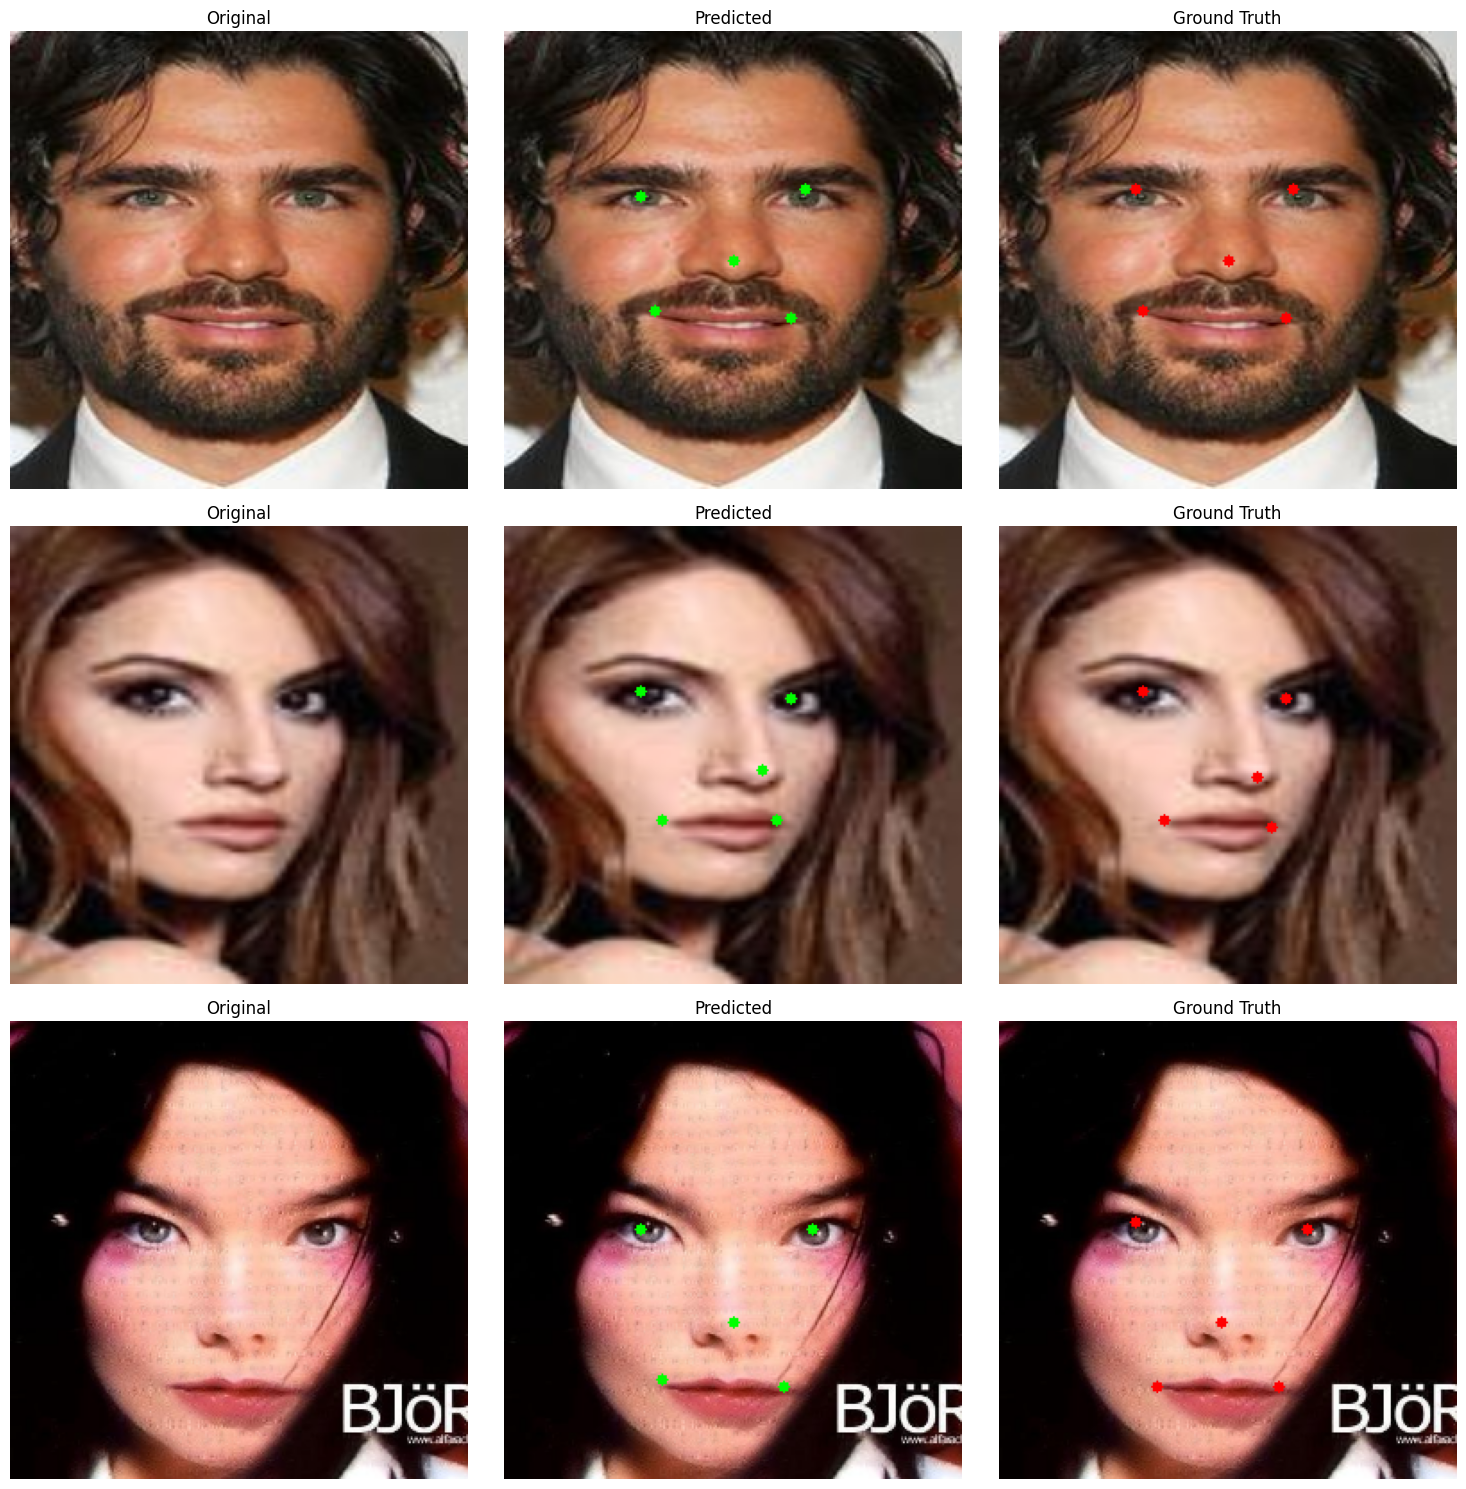

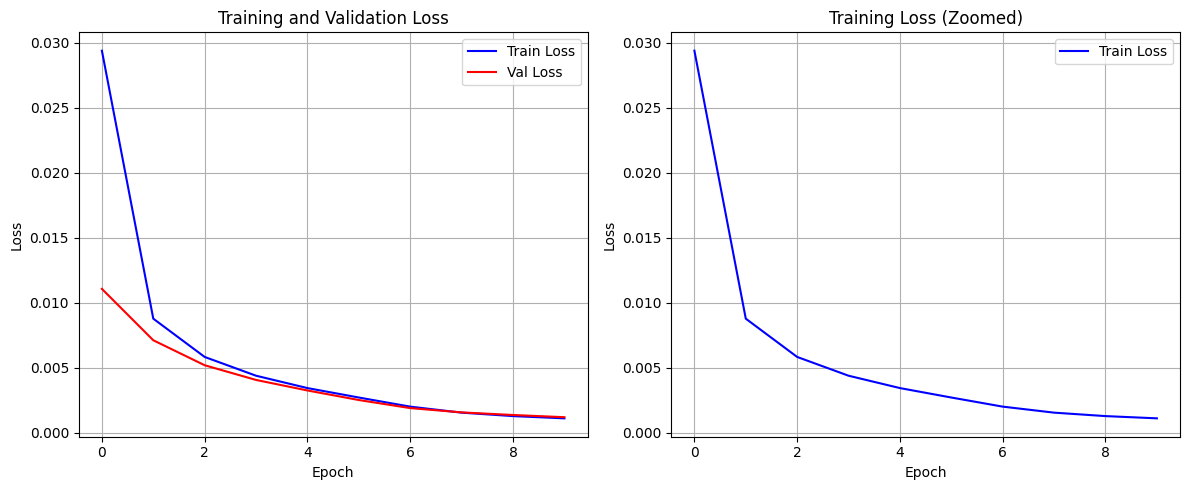


Обучение завершено
Лучший лосс на валидации: 0.001201


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

train_losses = []
val_losses = []
best_val_loss = float('inf')


# Функция для визуализации предсказаний
def visualize_predictions(model, dataloader, device, num_samples=3):
    model.eval()

    images, heatmaps = next(iter(dataloader))
    images = images[:num_samples].to(device)
    heatmaps = heatmaps[:num_samples]

    with torch.no_grad():
        predicted_heatmaps = model(images)
        final_heatmap = predicted_heatmaps[-1]

        pred_keypoints = heatmap_to_keypoints(final_heatmap.cpu())
        true_keypoints = heatmap_to_keypoints(heatmaps)

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    scale_x = 256 / 64
    scale_y = 256 / 64

    for i in range(num_samples):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        # Предсказанные точки
        img_pred = img.copy()
        for x, y in pred_keypoints[i]:
            cv2.circle(img_pred, (int(x * scale_x), int(y * scale_y)), 3, (0, 255, 0), -1)

        # Истинные точки
        img_true = img.copy()
        for x, y in true_keypoints[i]:
            cv2.circle(img_true, (int(x * scale_x), int(y * scale_y)), 3, (255, 0, 0), -1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img_pred)
        axes[i, 1].set_title("Predicted")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img_true)
        axes[i, 2].set_title("Ground Truth")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc='Training')
    for batch_idx, (images, heatmaps) in enumerate(pbar):
        images = images.to(device)
        heatmaps = heatmaps.to(device)

        optimizer.zero_grad()

        predicted_heatmaps = model(images)
        loss = heatmap_loss(predicted_heatmaps, heatmaps)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

        # Очищаем память
        if batch_idx % 10 == 0:
            torch.cuda.empty_cache()

    return total_loss / len(train_loader)


def validate(model, val_loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for images, heatmaps in pbar:
            images = images.to(device)
            heatmaps = heatmaps.to(device)

            predicted_heatmaps = model(images)
            loss = heatmap_loss(predicted_heatmaps, heatmaps)

            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(val_loader)

# ОБУЧЕНИЕ

num_epochs = 10

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, device)

    val_loss = validate(model, val_loader, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Сохраняем лучшую модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, '/content/drive/MyDrive/FR_project/best_model.pth')
        print(f"Сохранена лучшая модель, (val_loss: {val_loss:.6f})")

    # Выводим информацию об эпохе
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f} | "
          f"Time: {elapsed_time:.1f}s")
    print("-" * 60)

    # Визуализация каждые 5 эпох
    if (epoch + 1) % 5 == 0:
        visualize_predictions(model, val_loader, device, num_samples=3)

# График потерь
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss (Zoomed)')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nОбучение завершено")
print(f"Лучший лосс на валидации: {best_val_loss:.6f}")

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/FR_project/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
best_val_loss = checkpoint['val_loss']
print(f"Загружена лучшая модель, эпоха: {checkpoint['epoch']+1}")

In [ ]:
# использую афинное преобразование для выравнивания лиц по точкам
# определяем стандартное положение точек, к которому будем приводить лица
# нужно вычислить матрицу преобразования, которая приведет предсказанные точки к стандартным
# применяем это преобразование к изображению

In [ ]:
# немного меняю ранее написанную функцию (очень долго сидел над выравниванием почему то, а на войне все средства...)
def heatmap_to_keypoints_soft(heatmap):
    """
    Взвешенный центр масс heatmap'а вместо argmax -> координаты с sub-pixel точностью.
    heatmap: torch.Tensor [B, num_keypoints, H, W]
    """
    B, K, H, W = heatmap.shape
    heatmap = heatmap.clamp(min=0) + 1e-6  # убираем отрицательные значения

    heatmap_flat = heatmap.view(B, K, -1)
    weights = heatmap_flat / heatmap_flat.sum(dim=-1, keepdim=True)

    ys = torch.linspace(0, H - 1, H, device=heatmap.device)
    xs = torch.linspace(0, W - 1, W, device=heatmap.device)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    grid_x = grid_x.reshape(-1)
    grid_y = grid_y.reshape(-1)

    exp_x = (weights * grid_x).sum(dim=-1)  # [B, K]
    exp_y = (weights * grid_y).sum(dim=-1)

    keypoints = []
    for b in range(B):
        points = [(exp_x[b, k].item(), exp_y[b, k].item()) for k in range(K)]
        keypoints.append(points)
    return keypoints

In [ ]:
# Порядок точек как в CelebA / landmarks_dict:
# 0 - левый глаз, 1 - правый глаз, 2 - нос, 3 - левый угол рта, 4 - правый угол рта

# Эталонный шаблон arcface для изображения 112x112,
# масштабируем под нужный итоговый размер
ARCFACE_TEMPLATE_112 = np.array([
    [38.2946, 51.6963],   # левый глаз
    [73.5318, 51.5014],   # правый глаз
    [56.0252, 71.7366],   # нос
    [41.5493, 92.3655],   # левый угол рта
    [70.7299, 92.2041],   # правый угол рта
], dtype=np.float32)

In [ ]:
def get_reference_landmarks(output_size=256, base_size=112, zoom=1.15, chin_margin=0.06):
    """
    chin_margin - на сколько (в долях от output_size) сдвинуть эталонные точки
    ВВЕРХ по канве, освобождая больше места снизу под подбородок.
    0.0 - оригинальный ArcFace-баланс (много лба, мало подбородка).
    0.05-0.08 - обычно достаточно, чтобы подбородок влезал целиком.
    """
    template = ARCFACE_TEMPLATE_112 * (output_size / base_size)
    center = np.array([output_size / 2, output_size / 2], dtype=np.float32)
    template = center + (template - center) * zoom

    # сдвигаем landmarks вверх -> меньше лба, больше подбородка
    template[:, 1] -= chin_margin * output_size

    return template

In [ ]:
def predict_landmarks(model, image_bgr, device, input_size=256, heatmap_size=64):
    model.eval()
    orig_h, orig_w = image_bgr.shape[:2]

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, (input_size, input_size), interpolation=cv2.INTER_LINEAR)

    tensor = resized.astype(np.float32) / 255.0
    tensor = np.transpose(tensor, (2, 0, 1))
    tensor = torch.FloatTensor(tensor).unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_heatmaps = model(tensor)
        final_heatmap = predicted_heatmaps[-1]

    keypoints_hm = heatmap_to_keypoints(final_heatmap.cpu())[0]

    scale_x = orig_w / heatmap_size
    scale_y = orig_h / heatmap_size
    landmarks = [(x * scale_x, y * scale_y) for (x, y) in keypoints_hm]
    return landmarks

In [ ]:
def align_face(image_bgr, landmarks, output_size=256, zoom=1.15, chin_margin=0.13,
               max_scale_ratio=2.5, max_rotation_deg=45):
    src = np.array(landmarks, dtype=np.float32)
    dst = get_reference_landmarks(output_size=output_size, zoom=zoom, chin_margin=chin_margin)

    M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)

    if M is None:
        return cv2.resize(image_bgr, (output_size, output_size)), False

    # проверка на адекватность найденного преобразования
    a, b = M[0, 0], M[0, 1]
    scale = np.sqrt(a**2 + b**2)
    rotation_deg = np.degrees(np.arctan2(b, a))

    is_ok = (1 / max_scale_ratio < scale < max_scale_ratio) and (abs(rotation_deg) < max_rotation_deg)

    aligned = cv2.warpAffine(
        image_bgr, M, (output_size, output_size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )
    return aligned, is_ok

In [ ]:
def visualize_aligned_faces(model, dataset, device, num_samples=4, output_size=256):
    model.eval()
    filenames = dataset.filenames[:num_samples]
    colors = [(255, 0, 0), (0, 0, 255), (0, 180, 0), (255, 180, 0), (160, 0, 200)]

    fig, axes = plt.subplots(num_samples, 2, figsize=(8, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i, filename in enumerate(filenames):
        img_path = os.path.join(dataset.images_dir, filename)
        image = cv2.imread(img_path)

        landmarks = predict_landmarks(model, image, device)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        img_before = image_rgb.copy()
        r = max(2, image.shape[0] // 100)
        for c, (x, y) in zip(colors, landmarks):
            cv2.circle(img_before, (int(x), int(y)), r, c, -1)

        aligned, is_ok = align_face(image, landmarks, output_size=output_size)
        aligned_rgb = cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)

        axes[i, 0].imshow(img_before)
        axes[i, 0].set_title("ДО выравнивания")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(aligned_rgb)
        axes[i, 1].set_title("ПОСЛЕ выравнивания")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def create_aligned_dataset(model, images_dir, output_dir, device, output_size=256, zoom=1.15):
    os.makedirs(output_dir, exist_ok=True)
    model.eval()

    filenames = sorted(os.listdir(images_dir))
    saved, suspicious = 0, 0

    for filename in tqdm(filenames, desc=f'Выравнивание -> {os.path.basename(output_dir)}'):
        img_path = os.path.join(images_dir, filename)
        image = cv2.imread(img_path)
        if image is None:
            print(f"Пропущено (не удалось прочитать): {img_path}")
            continue

        landmarks = predict_landmarks(model, image, device)
        aligned, is_ok = align_face(image, landmarks, output_size=output_size, zoom=zoom)

        if not is_ok:
            suspicious += 1

        out_path = os.path.join(output_dir, filename)
        cv2.imwrite(out_path, aligned)
        saved += 1

    print(f"Готово: {saved}/{len(filenames)} сохранено в {output_dir} "
          f"(подозрительных выравниваний: {suspicious})")


In [ ]:
model = StackedHourglass(
    in_channels=3,
    num_stacks=4,
    num_keypoints=5,
    hidden_channels=256
)
model.to(device)

StackedHourglass(
  (input_conv): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ResidualBlock(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
      (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ResidualBlock(
      (skip): Identity()
      (con

In [ ]:
checkpoint = torch.load('/content/drive/MyDrive/FR_project/best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print(f"Модель загружена, эпоха: {checkpoint['epoch']+1}, val_loss: {checkpoint['val_loss']:.6f}")

Модель загружена, эпоха: 10, val_loss: 0.001201


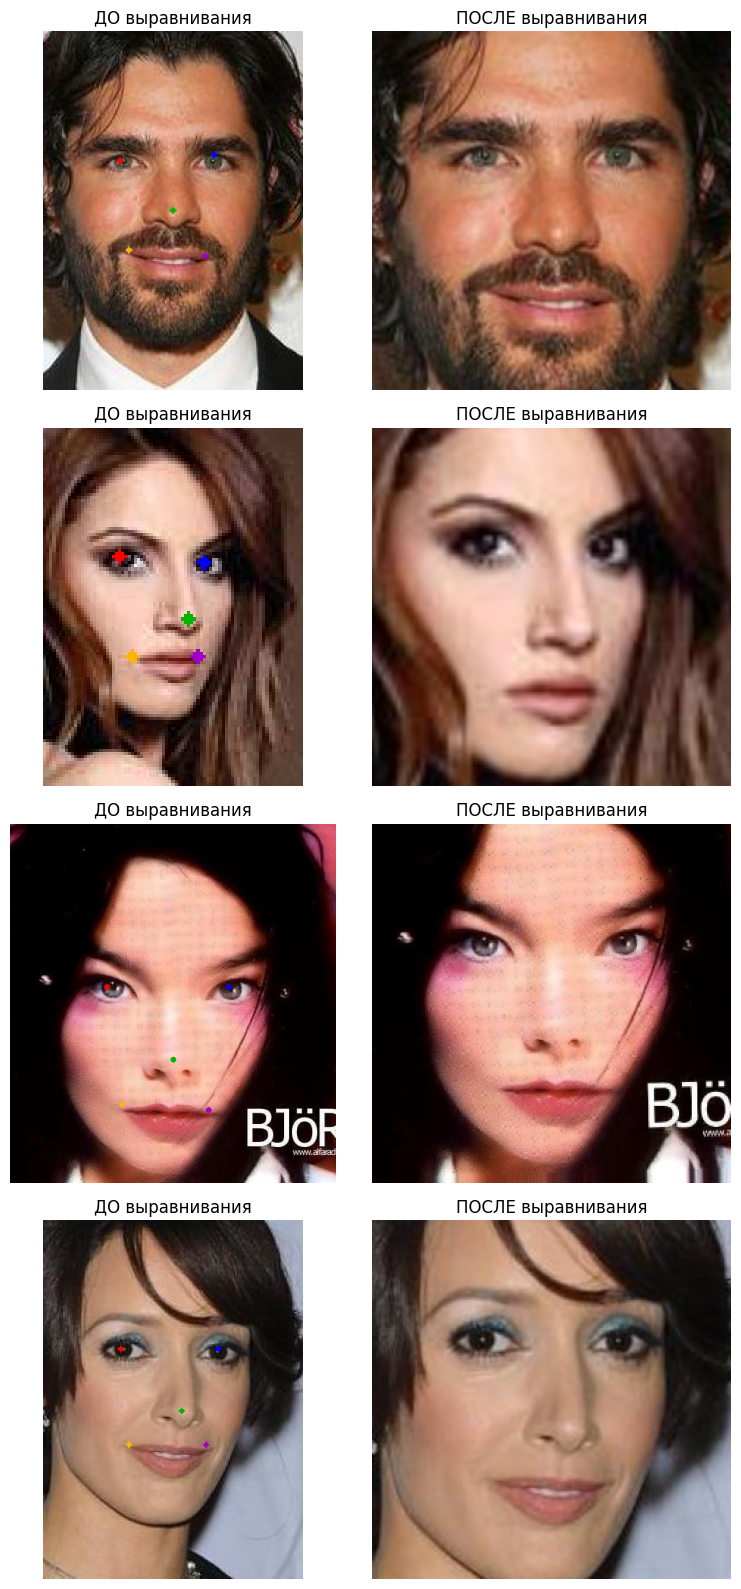

In [ ]:
visualize_aligned_faces(model, val_dataset, device, num_samples=4)

In [ ]:
aligned_root = '/content/drive/MyDrive/FR_project/AlignedDataset'
aligned_train_dir = os.path.join(aligned_root, 'aligned_train_data')
aligned_val_dir = os.path.join(aligned_root, 'aligned_val_data')

os.makedirs(aligned_train_dir, exist_ok=True)
os.makedirs(aligned_val_dir, exist_ok=True)

create_aligned_dataset(model, '/content/train_data_cropped', aligned_train_dir, device, output_size=256)
create_aligned_dataset(model, '/content/val_data_cropped', aligned_val_dir, device, output_size=256)


train_count = len([f for f in os.listdir(aligned_train_dir)
                    if os.path.isfile(os.path.join(aligned_train_dir, f))])
val_count = len([f for f in os.listdir(aligned_val_dir)
                  if os.path.isfile(os.path.join(aligned_val_dir, f))])

print("ИТОГ:")
print(f"  {aligned_train_dir}: {train_count} изображений")
print(f"  {aligned_val_dir}: {val_count} изображений")


Выравнивание -> aligned_train_data: 100%|██████████| 20000/20000 [14:47<00:00, 22.52it/s]


Готово: 20000/20000 сохранено в /content/drive/MyDrive/AlignedDataset/aligned_train_data (подозрительных выравниваний: 2554)


Выравнивание -> aligned_val_data: 100%|██████████| 2000/2000 [01:29<00:00, 22.39it/s]


Готово: 2000/2000 сохранено в /content/drive/MyDrive/AlignedDataset/aligned_val_data (подозрительных выравниваний: 277)
ИТОГ:
  /content/drive/MyDrive/AlignedDataset/aligned_train_data: 20000 изображений
  /content/drive/MyDrive/AlignedDataset/aligned_val_data: 2000 изображений
